In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t, chisquare
import seaborn as sns
import pingouin
from statsmodels.stats.proportion import proportions_ztest 

In [2]:
df= pd.read_feather('late_shipments.feather')
df.head()

,id,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,late_delivery,late,product_group,sub_classification,...,line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_kilograms,freight_cost_usd,freight_cost_groups,line_item_insurance_usd
0,36203.0,Nigeria,PMO - US,Direct Drop,EXW,Air,1.0,Yes,HRDT,HIV test,...,2996.0,266644.00,89.00,0.89,"Alere Medical Co., Ltd.",Yes,1426.0,33279.83,expensive,373.83
1,30998.0,Botswana,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,25.0,800.00,32.00,1.60,"Trinity Biotech, Plc",Yes,10.0,559.89,reasonable,1.72
2,69871.0,Vietnam,PMO - US,Direct Drop,EXW,Air,0.0,No,ARV,Adult,...,22925.0,110040.00,4.80,0.08,Hetero Unit III Hyderabad IN,Yes,3723.0,19056.13,expensive,181.57
3,17648.0,South Africa,PMO - US,Direct Drop,DDP,Ocean,0.0,No,ARV,Adult,...,152535.0,361507.95,2.37,0.04,"Aurobindo Unit III, India",Yes,7698.0,11372.23,expensive,779.41
4,5647.0,Uganda,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test - Ancillary,...,850.0,8.50,0.01,0.00,Inverness Japan,Yes,56.0,360.00,reasonable,0.01


In [3]:
# Dataset exploration
df.shape

(1000, 27)

In [4]:
# Calculate the percentage of late shipments sample
df_late_samp= (df['late_delivery'] == 1).mean()*100
print(f"The percentage of late shipments: {df_late_samp:.2f}%")

The percentage of late shipments: 6.10%


#### We make a hypothesis that the percentage of late deliveries are 6% (H0)
#### HA is that the proportion of the late shipments is greater than 6% (we need right tailed test)

In [5]:
# Computing bootstrap distribution of the mean of the late shipments for 5k times
boot_strap=[]
for i in range(5000):
    boot_strap.append((df.sample(frac=1, replace=True)['late_delivery'] == 1).mean()*100)
print(boot_strap)

[np.float64(6.3), np.float64(6.0), np.float64(5.1), np.float64(5.3), np.float64(6.1), np.float64(6.0), np.float64(6.5), np.float64(5.3), np.float64(7.000000000000001), np.float64(6.7), np.float64(4.3999999999999995), np.float64(6.1), np.float64(5.0), np.float64(6.5), np.float64(5.5), np.float64(7.3), np.float64(4.7), np.float64(7.3), np.float64(6.4), np.float64(4.1000000000000005), np.float64(5.5), np.float64(4.7), np.float64(7.199999999999999), np.float64(6.3), np.float64(6.800000000000001), np.float64(6.3), np.float64(7.3999999999999995), np.float64(7.6), np.float64(6.1), np.float64(4.9), np.float64(6.0), np.float64(5.7), np.float64(5.8999999999999995), np.float64(7.199999999999999), np.float64(6.1), np.float64(5.7), np.float64(7.1), np.float64(6.9), np.float64(5.2), np.float64(6.6000000000000005), np.float64(7.199999999999999), np.float64(6.6000000000000005), np.float64(6.1), np.float64(5.800000000000001), np.float64(5.1), np.float64(5.0), np.float64(6.3), np.float64(4.9), np.float6

In [6]:
# Std of the bootstrap distribution of the sample (ddof=1)
std_err= np.std(boot_strap, ddof=1)
std_err

np.float64(0.7511216220681093)

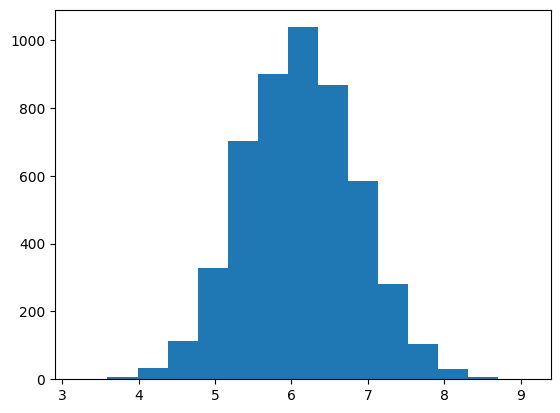

In [7]:
plt.hist(boot_strap, bins=15)
plt.show()

In [8]:
np.mean(boot_strap)

np.float64(6.116160000000001)

In [9]:
# Calucalting the z-score
hypothesis= 6
z_score= ((df['late_delivery'] == 1).mean()*100 - hypothesis)/std_err
z_score

np.float64(0.1331342316104062)

In [10]:
# Setting the alpha before performing the p-value calculation
alpha= 0.05

# Right tailed test
p_value= 1-norm.cdf(z_score, loc=0, scale=1)
print(f"p_value: {p_value:.3f}")

p_value: 0.447


In [11]:
if p_value <= alpha:
    print("Reject the null hypothesis. This means that the late shipment rate is greater than 6%.")
else:
    print("Fail to reject the null hypothesis. This means that the late shipment rate is 6%.")

Fail to reject the null hypothesis. This means that the late shipment rate is 6%.


In [12]:
# Calculaing the confidence interval of 95% ( the result of lower and upper are in percentage. ex. 4.6% and 7.6%)
lower= np.quantile(boot_strap, 0.025)
upper= np.quantile(boot_strap, 0.975)

print((lower, upper))

(np.float64(4.7), np.float64(7.6))


We are 95% sure that the % of the late delivereis (6% that we have hypothesized) lie between 4.7% and 7.6% that is in favor of null hypotheis (the percentagae of late deliveries is 6%). Therefore, the percentage of late deliveries is 6%

From this cell and later, we perform t-tests by weight of the shipments.

We want to check that if the shipments what were on-time were less than that of lates (left tail test is needed). 

In [13]:
# Calculating the population mean (mean weight)
xbar= df.groupby('late_delivery')['weight_kilograms'].mean()
xbar

late_delivery
0.0    1897.791267
1.0    2715.672131
Name: weight_kilograms, dtype: float64

In [14]:
# Calculating the population std (std weight)
s= df.groupby('late_delivery')['weight_kilograms'].std()
s

late_delivery
0.0    3154.039507
1.0    2544.688211
Name: weight_kilograms, dtype: float64

In [15]:
n= df.groupby('late_delivery')['weight_kilograms'].count()
n

late_delivery
0.0    939
1.0     61
Name: weight_kilograms, dtype: int64

In [16]:
numerator= xbar[0] - xbar[1]
numerator

np.float64(-817.8808638418964)

In [17]:
denuminator= np.sqrt((s[1]**2)/n[1] + (s[0]**2)/n[0])
denuminator

np.float64(341.68543274794337)

In [18]:
t_stat= numerator/denuminator
t_stat


np.float64(-2.3936661778766433)

In [19]:
# To perform the t-test, we assume the significance level is 5%
alpha= 0.05
df_degrees_freedom= n[0] + n[1] -2

# The right tailed test
p_value= t.cdf(t_stat, df=df_degrees_freedom)
p_value


np.float64(0.008432382146249523)

Since p<alpha, therefore, we reject the H0. This means that shipments that were not late(on-time), had lower weight.

Now we conduct an ANOVA test on the late shipment dataset to see if there is a difference btw different methods of delivery on the pack price. 

H0: Different shipment modes do not have any effect on the pack price.

HA: Pack price for some categories of shipment modes are different.

We assume alpha as 0.1

In [20]:
# Claculate the mean pack price for different shipment methods
x_bar_pack_by_mode= df.groupby('shipment_mode')['pack_price'].mean()
x_bar_pack_by_mode

shipment_mode
Air            39.712395
Air Charter     4.226667
Ocean           6.432273
Name: pack_price, dtype: float64

In [21]:
# Claculate the std pack price for different shipment methods
s_pack_by_mode= df.groupby('shipment_mode')['pack_price'].std()
s_pack_by_mode

shipment_mode
Air            48.932861
Air Charter     0.992969
Ocean           5.303047
Name: pack_price, dtype: float64

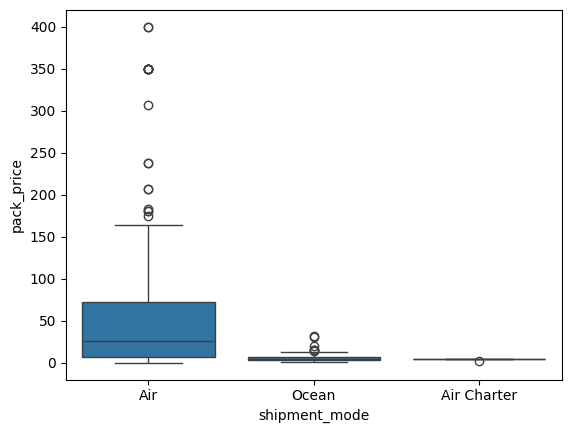

In [22]:
# Data visualiztion for pack price by shipment mode (EDA) using seaborn boxplot before performing ANOVA test
sns.boxplot(x='shipment_mode', y='pack_price', data=df)
plt.show()

In [23]:
# Using the pengouin library to perform ANOVA test
anova_results= pingouin.anova(data=df, dv='pack_price', between='shipment_mode')
anova_results

,Source,ddof1,ddof2,F,p-unc,np2
0,shipment_mode,2,997,21.8646,5.089479e-10,0.042018


p-value <0.1 (alpha), so the H0 must be rejected that is at least there are difference between some categories of shipment modes.

In [24]:
# Conducting pairwise t-test and using Bonferroni correction (comparing different shipment modes or categories)
pairwise_results= pingouin.pairwise_tests(data=df, dv='pack_price', between='shipment_mode', padjust='bonf')
pairwise_results

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,shipment_mode,Air,Air Charter,False,True,21.179625,600.685682,two-sided,8.748346e-75,2.624504e-74,bonf,5.809e+76,0.726592
1,shipment_mode,Air,Ocean,False,True,19.335760,986.979785,two-sided,6.934555e-71,2.080367e-70,bonf,1.129e+67,0.711119
2,shipment_mode,Air Charter,Ocean,False,True,-3.170654,35.615026,two-sided,3.123012e-03,9.369037e-03,bonf,15.277,-0.423775


Having a look at the Bonferroni correction p-values, all of them are lower than the significance level of alpha (0.1). This means that the H0 hypothesis must be rejected. Therefore, we accept the HA,saying that if we use different shipment modes, it affects the pack price. (ANOVA test result). 

Now we perform two-sample proportion tests. (late delivery test on their freight costs)

We want to test if the there is difference in the freight cost in late deliveries or not.

H0: There is no difference in the freight cost of late shipments.

HA: The fregiht cost late shimpments are higher than that of reasonable shipments. (right tail test)

We use proportions ztest from statsmodels to test this hypothesis.

In [25]:
# group the population by freight cost groups and count how many of them were late
late_by_freight_cost_group = df.groupby('freight_cost_groups')['late_delivery'].value_counts()
late_by_freight_cost_group

freight_cost_groups  late_delivery
expensive            0.0              489
                     1.0               42
reasonable           0.0              439
                     1.0               16
Name: count, dtype: int64

In [26]:
# Creating an array of counts of late and on-time deliveries for each freight cost group
count_late_expensive_reasonable = np.array([42, 16])
# Create an array of total deliveries for each freight cost group
n_rows = np.array([489+42, 439+16])

# Performing two-proportion z-test
z_stat, p_value= proportions_ztest(count_late_expensive_reasonable, n_rows, alternative='larger')
z_stat, p_value

(np.float64(2.922648567784529), np.float64(0.001735340002359578))

0.001< 0.05 we reject the H0. This means that there freight cost of late shipments are higher than that of on-time shipments.

Now, we conduct a chi-square test to see if : vendor_inco_term and freight_cost_group are independent.


In [27]:
# Setting the significance level
alpha= 0.01
# Group our dataset by freight cost groups and calculate the proportion of each vendor inco term within those groups
prop= df.groupby('freight_cost_groups')['vendor_inco_term'].value_counts(normalize=True)
prop

freight_cost_groups  vendor_inco_term
expensive            EXW                 0.796610
                     DDP                 0.103578
                     FCA                 0.069680
                     CIP                 0.030132
reasonable           EXW                 0.663736
                     FCA                 0.160440
                     DDP                 0.098901
                     CIP                 0.074725
                     DDU                 0.002198
Name: proportion, dtype: float64

<Axes: xlabel='freight_cost_groups'>

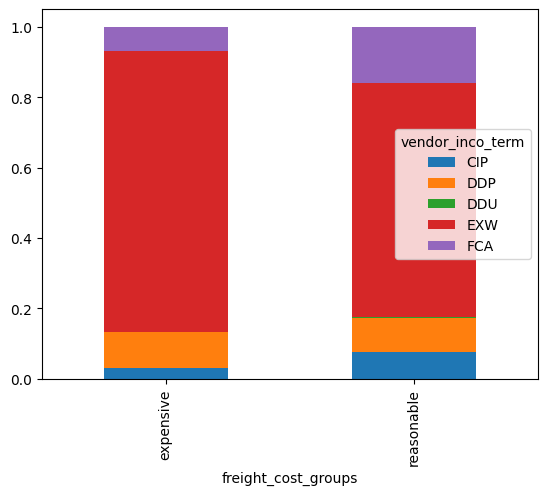

In [28]:
# making it unstacked for better visualization
wide_prop= prop.unstack()
# Visulaizing the proportions using a bar plot
wide_prop.plot(kind='bar', stacked=True)

In [29]:
# Performing chi-square test of independence using pengouin library
chi2_results= pingouin.chi2_independence(data=df, x='freight_cost_groups', y='vendor_inco_term')
chi2_results


c:\Users\Hossein\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Hossein\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Hossein\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:7409: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Hossein\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:7409: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Hossein\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:7406: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 *

(vendor_inco_term           CIP        DDP      DDU         EXW        FCA
 freight_cost_groups                                                      
 expensive            26.926978  53.853955  0.53854  390.441176  59.239351
 reasonable           23.073022  46.146045  0.46146  334.558824  50.760649,
 vendor_inco_term     CIP  DDP  DDU  EXW  FCA
 freight_cost_groups                         
 expensive             16   55    0  423   37
 reasonable            34   45    1  302   73,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  34.805072  4.0  5.093922e-07  0.186561   
 1        cressie-read  0.666667  34.845134  4.0  4.998337e-07  0.186669   
 2      log-likelihood  0.000000  35.442911  4.0  3.767119e-07  0.188263   
 3       freeman-tukey -0.500000        NaN  4.0           NaN       NaN   
 4  mod-log-likelihood -1.000000        inf  4.0  0.000000e+00       inf   
 5              neyman -2.000000        NaN  4.0          

Since the p-value is less than the significance level which is 0.01, therefore, the vendor_inco_term and freight_cost_groups are independent

From this cell afterwards, we conduct chi-square goodness of fit test using scipy.stat library in Python. 

H0: : The sample matches with the hypothesized distribution.

HA: The sample does not match with the hypothesized distribution

alpha= 0.1

In [30]:
print(df['vendor_inco_term'].unique())

['EXW' 'DDP' 'CIP' 'FCA' 'DDU']


We assume these proportions for different categories of vendor_inco_term column

Hypothesis:

CIP: 0.05

DDP: 0.05

EXW: 0.75

FCA: 0.05

DDU: 0.1

In [31]:
# We start to create a dataframe with pandas to check of the distribution of vendor inco terms matches our hypothesis. Generating the hypothesized
hypothesized = pd.DataFrame({ 
'vendor_inco_term': ['CIP', 'DDP', 'EXW', 'FCA', 'DDU'],  
'prop': [0.05, 0.05, 0.75, 0.05, 0.10]})
hypothesized 

,vendor_inco_term,prop
0,CIP,0.05
1,DDP,0.05
2,EXW,0.75
3,FCA,0.05
4,DDU,0.10


In [32]:
# We crate a dataframe to calculate the observed counts of vendor inco terms
observed_counts= df['vendor_inco_term'].value_counts()
observed_counts

vendor_inco_term
EXW    732
FCA    111
DDP    100
CIP     56
DDU      1
Name: count, dtype: int64

In [33]:
# We do some data manipulation to align the observed counts with the hypothesized proportions
observed_counts= observed_counts.rename_axis('vendor_inco_term').reset_index(name='n').sort_values('vendor_inco_term')
observed_counts

,vendor_inco_term,n
3,CIP,56
2,DDP,100
4,DDU,1
0,EXW,732
1,FCA,111


In [34]:
# Set the significance level
alpha= 0.1

# Calculate the toal number of observations
n_total= len(df)
n_total

1000

In [35]:
hypothesized['n']= hypothesized['prop'] * n_total
hypothesized

,vendor_inco_term,prop,n
0,CIP,0.05,50.0
1,DDP,0.05,50.0
2,EXW,0.75,750.0
3,FCA,0.05,50.0
4,DDU,0.10,100.0


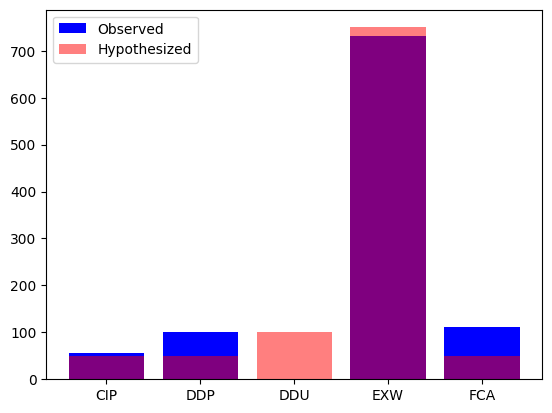

In [36]:
# Visualizing the observed vs hypothesized counts using a bar plot
plt.bar(observed_counts['vendor_inco_term'], observed_counts['n'], label='Observed', color='blue')
plt.bar(hypothesized['vendor_inco_term'], hypothesized['n'], alpha=0.5, label='Hypothesized', color='red')
plt.legend()
plt.show()

In [37]:
# Running the chi-square goodness of fit test using pingouin library
chi2_gof= chisquare(f_obs= observed_counts['n'], f_exp= hypothesized['n'])
chi2_gof

Power_divergenceResult(statistic=np.float64(10102.411333333332), pvalue=np.float64(0.0))

Since p<0.1, we reject the H0 meaning that the distribution of different categories of the incoterms are difference from our hypothesized value

Testing the sample size to see if it is possible to conduct parametric test

In [38]:
df.columns

Index(['id', 'country', 'managed_by', 'fulfill_via', 'vendor_inco_term',
       'shipment_mode', 'late_delivery', 'late', 'product_group',
       'sub_classification', 'vendor', 'item_description',
       'molecule_test_type', 'brand', 'dosage', 'dosage_form',
       'unit_of_measure_per_pack', 'line_item_quantity', 'line_item_value',
       'pack_price', 'unit_price', 'manufacturing_site',
       'first_line_designation', 'weight_kilograms', 'freight_cost_usd',
       'freight_cost_groups', 'line_item_insurance_usd'],
      dtype='object')

In [39]:
# Count the freight_cost_group values
counts = df['freight_cost_groups'].value_counts()

# Print the result
print(counts)

# Inspect whether the counts are big enough
print((counts >= 30).all())

freight_cost_groups
expensive     531
reasonable    455
Name: count, dtype: int64
True


The sample is big enough to perform the two-sample t-test.

From this cell afterwards, we conduct some non-parametric tests like Wilcoxon-Mann-Whitney test. We set the alpha equal to 0.01.

H0: There is no difference between weight of shipments and whether they are late or not

HA: There is a difference in weight of the shipments and whether they are late or not

In [40]:
# Select the weight_kilograms and late columns
weight_vs_late = df[['weight_kilograms','late']]

# Convert weight_vs_late into wide format
weight_vs_late_wide = weight_vs_late.pivot(columns='late', 
                                           values='weight_kilograms')


# Run a two-sided Wilcoxon-Mann-Whitney test on weight_kilograms vs. late
wmw_test = pingouin.mwu(x=weight_vs_late_wide['No'], y=weight_vs_late_wide['Yes'], alternative='two-sided')



# Print the test results
print(wmw_test)

       U-val alternative     p-val       RBC      CLES
MWU  19134.0   two-sided  0.000014 -0.331902  0.334049


Due to small p-value and since it is less than alpha, we reject H0, and thus there is a difference in weight of shipments and whether they are late or not

Now we conduct Kruskal-Wallis test that is the non-parametric verion of ANOVA test, comparing means across multiple groups.

Here we set alpha again to 0.01

H0: There is no difference in weight distribution amongst different shipment modes.

HA: There is a difference in weight distribution amongst different shipment modes. (two-sided test)

In [41]:
# Run a Kruskal-Wallis test on weight_kilograms vs. shipment_mode
kw_test = pingouin.kruskal(data=df, dv='weight_kilograms', between='shipment_mode')



# Print the results
print(kw_test)

                Source  ddof1           H         p-unc
Kruskal  shipment_mode      2  125.096618  6.848799e-28


Due to small p-value, we reject the H0. So, there is a difference in weight distribution of different shipment modes.